In [1]:
# Libraries
!pip install -q transformers datasets evaluate scikit-learn accelerate

import torch
import numpy as np
import pandas as pd
import re
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# GPU Check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00
Using device: cuda


In [2]:
# Task 1 & 2: Load Data and Split
# We use the 'tweet_eval' sentiment dataset (0: negative, 1: neutral, 2: positive)
print("Loading Twitter Sentiment Dataset...")
dataset = load_dataset("tweet_eval", "sentiment")

# If you have more time, you can increase these numbers.
train_df = pd.DataFrame(dataset['train']).sample(2000, random_state=42)
val_df = pd.DataFrame(dataset['validation']).sample(500, random_state=42)
test_df = pd.DataFrame(dataset['test']).sample(500, random_state=42)

# Preprocessing Function
def clean_tweet(text):
    text = re.sub(r'@[A-Za-z0-9_]+', '', text) # Remove mentions
    text = re.sub(r'http\S+', '', text)        # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)    # Remove special characters
    return text.lower().strip()

# Apply cleaning
train_df['text'] = train_df['text'].apply(clean_tweet)
val_df['text'] = val_df['text'].apply(clean_tweet)
test_df['text'] = test_df['text'].apply(clean_tweet)

print("Data Splitting and Preprocessing Complete!")
print(f"Train size: {len(train_df)}, Val size: {len(val_df)}, Test size: {len(test_df)}")

Loading Twitter Sentiment Dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Data Splitting and Preprocessing Complete!
Train size: 2000, Val size: 500, Test size: 500


In [3]:
# Task 3: Tokenization
from datasets import Dataset

# Convert Pandas Dataframes back to Hugging Face Datasets
train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
test_ds = Dataset.from_pandas(test_df)

model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    # Padding and truncation to handle varying sentence lengths
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Tokenize datasets
print("Tokenizing datasets...")
tokenized_train = train_ds.map(tokenize_function, batched=True)
tokenized_val = val_ds.map(tokenize_function, batched=True)
tokenized_test = test_ds.map(tokenize_function, batched=True)
print("Tokenization complete!")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing datasets...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenization complete!


In [4]:
# Define evaluation metrics for the Trainer
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted', zero_division=0)
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [6]:
# Experiment 1: Freeze BERT and train only the classifier
import logging
logging.getLogger("transformers").setLevel(logging.ERROR) # Suppress the load warnings
print("--- Experiment 1: Freezing BERT Layers ---")

# Load model (3 labels: negative, neutral, positive)
model_frozen = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

# Freeze all layers of BERT
for param in model_frozen.bert.parameters():
    param.requires_grad = False

# Ensure classifier is trainable
for param in model_frozen.classifier.parameters():
    param.requires_grad = True

# Training Arguments (Changed 'evaluation_strategy' to 'eval_strategy')
training_args_frozen = TrainingArguments(
    output_dir="./results_frozen",
    eval_strategy="epoch",  # <-- FIXED HERE
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    logging_dir='./logs',
)

trainer_frozen = Trainer(
    model=model_frozen,
    args=training_args_frozen,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

print("Training Frozen Model...")
trainer_frozen.train()

# Predict on test set
print("Evaluating Frozen Model on Test Set...")
preds_frozen = trainer_frozen.predict(tokenized_test)
results_frozen = preds_frozen.metrics
print(results_frozen)

--- Experiment 1: Freezing BERT Layers ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Training Frozen Model...
{'eval_loss': '1.034', 'eval_accuracy': '0.46', 'eval_f1': '0.3846', 'eval_precision': '0.3939', 'eval_recall': '0.46', 'eval_runtime': '3.177', 'eval_samples_per_second': '157.4', 'eval_steps_per_second': '19.83', 'epoch': '1'}
{'eval_loss': '1.033', 'eval_accuracy': '0.464', 'eval_f1': '0.4125', 'eval_precision': '0.3862', 'eval_recall': '0.464', 'eval_runtime': '3.254', 'eval_samples_per_second': '153.6', 'eval_steps_per_second': '19.36', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': '1.033', 'eval_accuracy': '0.462', 'eval_f1': '0.4129', 'eval_precision': '0.3844', 'eval_recall': '0.462', 'eval_runtime': '3.417', 'eval_samples_per_second': '146.3', 'eval_steps_per_second': '18.44', 'epoch': '3'}
{'train_runtime': '55.67', 'train_samples_per_second': '107.8', 'train_steps_per_second': '6.737', 'train_loss': '1.015', 'epoch': '3'}
Evaluating Frozen Model on Test Set...
{'test_loss': 1.1910326480865479, 'test_accuracy': 0.434, 'test_f1': 0.32443825774584645, 'test_precision': 0.27712357217030115, 'test_recall': 0.434, 'test_runtime': 3.358, 'test_samples_per_second': 148.898, 'test_steps_per_second': 18.761}


In [7]:
# Experiment 2: Fine-tune the last 2 layers of BERT
print("--- Experiment 2: Fine-Tuning Last 2 Layers ---")

model_finetuned = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

# Freeze all layers first
for param in model_finetuned.bert.parameters():
    param.requires_grad = False

# Unfreeze the last 2 encoder layers (Layer 10 and 11 in BERT-base)
for param in model_finetuned.bert.encoder.layer[10:].parameters():
    param.requires_grad = True

# Unfreeze the pooler
for param in model_finetuned.bert.pooler.parameters():
    param.requires_grad = True

# Unfreeze the classifier
for param in model_finetuned.classifier.parameters():
    param.requires_grad = True

# Training Arguments (Changed 'evaluation_strategy' to 'eval_strategy')
training_args_finetuned = TrainingArguments(
    output_dir="./results_finetuned",
    eval_strategy="epoch",  # <-- FIXED HERE
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
)

trainer_finetuned = Trainer(
    model=model_finetuned,
    args=training_args_finetuned,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

print("Training Fine-Tuned Model...")
trainer_finetuned.train()

# Predict on test set
print("Evaluating Fine-Tuned Model on Test Set...")
preds_finetuned = trainer_finetuned.predict(tokenized_test)
results_finetuned = preds_finetuned.metrics
print(results_finetuned)

--- Experiment 2: Fine-Tuning Last 2 Layers ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Training Fine-Tuned Model...
{'eval_loss': '0.9677', 'eval_accuracy': '0.54', 'eval_f1': '0.4891', 'eval_precision': '0.4473', 'eval_recall': '0.54', 'eval_runtime': '3.519', 'eval_samples_per_second': '142.1', 'eval_steps_per_second': '17.91', 'epoch': '1'}
{'eval_loss': '0.8742', 'eval_accuracy': '0.574', 'eval_f1': '0.5523', 'eval_precision': '0.5713', 'eval_recall': '0.574', 'eval_runtime': '3.755', 'eval_samples_per_second': '133.2', 'eval_steps_per_second': '16.78', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': '0.8405', 'eval_accuracy': '0.636', 'eval_f1': '0.6216', 'eval_precision': '0.6312', 'eval_recall': '0.636', 'eval_runtime': '3.918', 'eval_samples_per_second': '127.6', 'eval_steps_per_second': '16.08', 'epoch': '3'}
{'train_runtime': '77.36', 'train_samples_per_second': '77.56', 'train_steps_per_second': '4.847', 'train_loss': '0.9267', 'epoch': '3'}
Evaluating Fine-Tuned Model on Test Set...
{'test_loss': 0.8811489939689636, 'test_accuracy': 0.558, 'test_f1': 0.5430242839841966, 'test_precision': 0.5774325928971139, 'test_recall': 0.558, 'test_runtime': 3.9688, 'test_samples_per_second': 125.983, 'test_steps_per_second': 15.874}


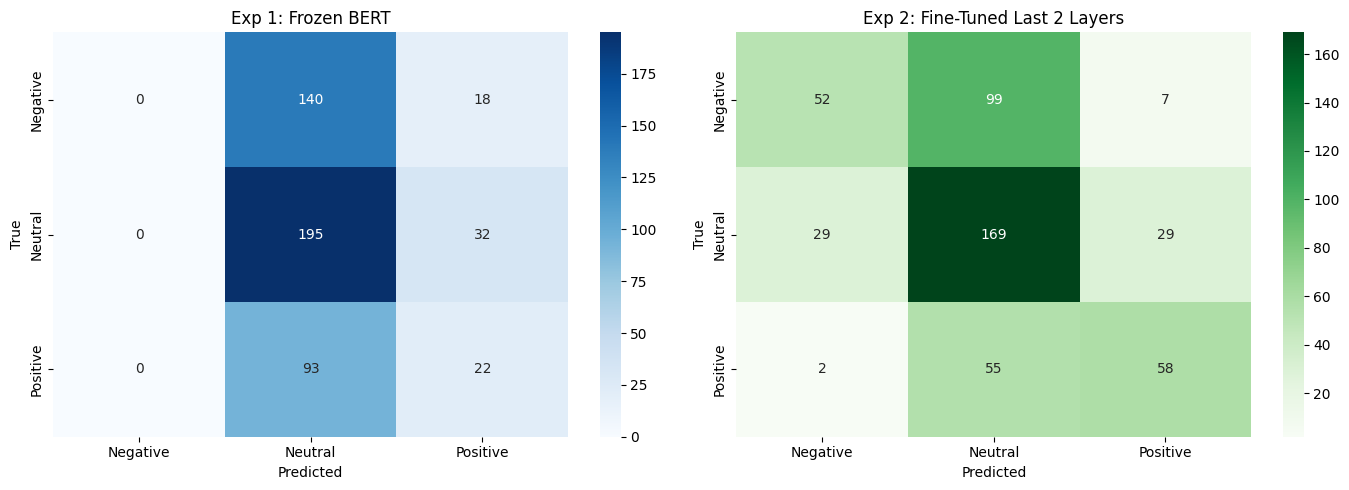


--- Model Performance Comparison ---


,Metric,Exp 1: Frozen BERT,Exp 2: Fine-Tuned (2 Layers)
0,Accuracy,0.4340,0.5580
1,Precision,0.2771,0.5774
2,Recall,0.4340,0.5580
3,F1 Score,0.3244,0.5430


In [9]:
# Task 6: Evaluation, Confusion Matrix & Comparison
from IPython.display import display
import pandas as pd

true_labels = tokenized_test['label']
pred_labels_frozen = preds_frozen.predictions.argmax(-1)
pred_labels_finetuned = preds_finetuned.predictions.argmax(-1)

# 1. Plotting Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_frozen = confusion_matrix(true_labels, pred_labels_frozen)
cm_finetuned = confusion_matrix(true_labels, pred_labels_finetuned)
classes =['Negative', 'Neutral', 'Positive']

sns.heatmap(cm_frozen, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title('Exp 1: Frozen BERT')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_finetuned, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title('Exp 2: Fine-Tuned Last 2 Layers')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

# 2. Comparison Table
print("\n--- Model Performance Comparison ---")
metrics_data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Exp 1: Frozen BERT":[
        results_frozen.get('test_accuracy', 0),
        results_frozen.get('test_precision', 0),
        results_frozen.get('test_recall', 0),
        results_frozen.get('test_f1', 0)
    ],
    "Exp 2: Fine-Tuned (2 Layers)":[
        results_finetuned.get('test_accuracy', 0),
        results_finetuned.get('test_precision', 0),
        results_finetuned.get('test_recall', 0),
        results_finetuned.get('test_f1', 0)
    ]
}

comparison_df = pd.DataFrame(metrics_data)

# Round the values to 4 decimal places for a clean look
comparison_df["Exp 1: Frozen BERT"] = comparison_df["Exp 1: Frozen BERT"].round(4)
comparison_df["Exp 2: Fine-Tuned (2 Layers)"] = comparison_df["Exp 2: Fine-Tuned (2 Layers)"].round(4)

# display() renders it as a nice HTML table in Colab
display(comparison_df)